# Pasos para empezar el analisis de datos
- EDA: exploracion los datos (nulos, duplicados, columnas, tipos de datos, info)
- Limpieza y transformación
- Union de datos
- Guardar los datos limpios**
- Analisis: 
    - Estadistica descriptiva
    - Correlaciones
    - Visualizaciones
- Informe resultados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [20]:
df_productos =  pd.read_csv('files/productos_dia_con_categorias.csv')
df_precios = pd.read_csv('files/precios_productos.csv') 

In [21]:
df_productos.head()

,Unnamed: 0,supermarket,name,description,product_id,categoria,subcategoria
0,2362486,dia-es,MISTOL lavavajillas mano original botella 900 ml,NaN,9e2fda45e63337294f2a604178823026,cuidado del hogar,lavavajillas
1,2362487,dia-es,DIA lavavajillas máquina premium todo en uno e...,NaN,244994c762813d38881cb118742152a2,cuidado del hogar,lavavajillas
2,2362488,dia-es,FAIRY lavavajillas máquina platinum azul en cá...,NaN,8a5398b602e44b93a0c0a4a7b9d22b84,cuidado del hogar,lavavajillas
3,2362489,dia-es,FAIRY lavavajillas máquina platinum plus limón...,NaN,2cd7ea87b1963adb51d8e1295f6c14d3,cuidado del hogar,lavavajillas
4,2362501,dia-es,FAIRY lavavajillas mano concentrado aloe vera ...,NaN,4abac3d30922f81012d7ae0c2cd955f2,cuidado del hogar,lavavajillas


In [22]:
df_precios.head()

,Unnamed: 0,price,reference_price,product_id,reference_unit,insert_date
0,6837303,"0,7","0,7",9b1d806ddaed2a3b4c842c361e9171a8,ud,2022-06-08 00:00:00
1,5137438,"3,19","10,63",baf038a3f001812899adb8beaf4e0ec7,kg,2022-02-10 00:00:00
2,6005999,"3,99","15,96",ca2fc753e5ea44e8c95888983c1dafe1,l,2022-04-11 00:00:00
3,6995217,"3,39","5,22",48c959cc94d6d82d1151189b2abe9e83,l,2022-06-19 00:00:00
4,5760664,"2,79","0,47",8904722366039ba8f147e2e75a5d1ce1,ud,2022-03-25 00:00:00


In [8]:
## EDA
df_productos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11494 entries, 2362486 to 7838355
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   supermarket   11494 non-null  object 
 1   name          11494 non-null  object 
 2   description   0 non-null      float64
 3   product_id    11494 non-null  object 
 4   categoria     11494 non-null  object 
 5   subcategoria  11494 non-null  object 
dtypes: float64(1), object(5)
memory usage: 628.6+ KB


In [14]:
df_productos.duplicated().sum()

np.int64(0)

In [13]:
df_productos.drop_duplicates(subset=['product_id'], keep='first', inplace=True)

In [17]:
df_productos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9496 entries, 2362486 to 7799546
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   supermarket   9496 non-null   object 
 1   name          9496 non-null   object 
 2   description   0 non-null      float64
 3   product_id    9496 non-null   object 
 4   categoria     9496 non-null   object 
 5   subcategoria  9496 non-null   object 
dtypes: float64(1), object(5)
memory usage: 519.3+ KB


In [9]:
df_precios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000000 entries, 6837303 to 5813238
Data columns (total 5 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   price            999999 non-null   object
 1   reference_price  999999 non-null   object
 2   product_id       1000000 non-null  object
 3   reference_unit   998391 non-null   object
 4   insert_date      1000000 non-null  object
dtypes: object(5)
memory usage: 45.8+ MB


In [18]:
df_final = df_productos.merge(df_precios, on=['product_id'], how='right')

In [19]:
df_final.head()

,supermarket,name,description,product_id,categoria,subcategoria,price,reference_price,reference_unit,insert_date
0,dia-es,DIA SUPER PACO guantes satinados talla S bolsa...,NaN,9b1d806ddaed2a3b4c842c361e9171a8,cuidado del hogar,utensilios de limpieza,"0,7","0,7",ud,2022-06-08 00:00:00
1,dia-es,KELLOGGS cereales special k con frutas rojas c...,NaN,baf038a3f001812899adb8beaf4e0ec7,despensa,desayunos y dulces,"3,19","10,63",kg,2022-02-10 00:00:00
2,dia-es,DIA IMAQE leche solar infantil spf 50+ tubo 25...,NaN,ca2fc753e5ea44e8c95888983c1dafe1,cuidado personal,cuidado corporal,"3,99","15,96",l,2022-04-11 00:00:00
3,dia-es,SANEX gel de ducha dermo protector piel normal...,NaN,48c959cc94d6d82d1151189b2abe9e83,cuidado personal,bano e higiene personal,"3,39","5,22",l,2022-06-19 00:00:00
4,dia-es,COLHOGAR papel higiénico XXL paquete 6 uds,NaN,8904722366039ba8f147e2e75a5d1ce1,cuidado del hogar,papel,"2,79","0,47",ud,2022-03-25 00:00:00


In [23]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   supermarket      1000000 non-null  object 
 1   name             1000000 non-null  object 
 2   description      0 non-null        float64
 3   product_id       1000000 non-null  object 
 4   categoria        1000000 non-null  object 
 5   subcategoria     1000000 non-null  object 
 6   price            999999 non-null   object 
 7   reference_price  999999 non-null   object 
 8   reference_unit   998391 non-null   object 
 9   insert_date      1000000 non-null  object 
dtypes: float64(1), object(9)
memory usage: 76.3+ MB


In [24]:
## eliminar columns
df_final.drop(columns=['description'], inplace=True)

In [25]:
df_final.duplicated().sum()

np.int64(0)

In [26]:
df_final.isnull().sum()

supermarket           0
name                  0
product_id            0
categoria             0
subcategoria          0
price                 1
reference_price       1
reference_unit     1609
insert_date           0
dtype: int64

In [34]:
df_final['reference_unit'].value_counts()

reference_unit
kg             496396
l              354008
ud             135977
lavado          10874
Desconocido      1609
m                1136
Name: count, dtype: int64

In [33]:
df_final['reference_unit'].unique()

array(['ud', 'kg', 'l', 'lavado', 'Desconocido', 'm'], dtype=object)

In [35]:
# df_final.fillna({'reference_unit':'desconocido'}, inplace=True)version 3.13 en adelante
#df_final['reference_unit'].fillna("Desconocido", inplace=True) version 3.11
df_final['reference_unit'] = df_final['reference_unit'].fillna('Desconocido')

In [36]:
## limpiar/mofdificat price y reference price
df_final['price'].unique()

array(['0,7', '3,19', '3,99', ..., nan, '8,28', '14,89'], dtype=object)

In [37]:
## cambir la coma por el punto
## cambiar el object por float
columnas = ['price', 'reference_price']
for col in columnas: 
    df_final[col]= df_final[col].str.replace(',', '.')
    df_final[col] = df_final[col].astype(float)

In [38]:
df_final.dtypes

supermarket         object
name                object
product_id          object
categoria           object
subcategoria        object
price              float64
reference_price    float64
reference_unit      object
insert_date         object
dtype: object

In [39]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   supermarket      1000000 non-null  object 
 1   name             1000000 non-null  object 
 2   product_id       1000000 non-null  object 
 3   categoria        1000000 non-null  object 
 4   subcategoria     1000000 non-null  object 
 5   price            999999 non-null   float64
 6   reference_price  999999 non-null   float64
 7   reference_unit   1000000 non-null  object 
 8   insert_date      1000000 non-null  object 
dtypes: float64(2), object(7)
memory usage: 68.7+ MB


In [43]:
## transformacion de date
df_final['insert_date'].unique()

array(['2022-06-08 00:00:00', '2022-02-10 00:00:00',
       '2022-04-11 00:00:00', '2022-06-19 00:00:00',
       '2022-03-25 00:00:00', '2021-12-31 00:00:00',
       '2022-07-13 00:00:00', '2021-10-26 00:00:00',
       '2022-07-02 00:00:00', '2021-11-07 00:00:00',
       '2021-11-01 00:00:00', '2022-01-17 00:00:00',
       '2021-09-19 00:00:00', '2022-07-22 00:00:00',
       '2022-04-22 00:00:00', '2021-12-08 00:00:00',
       '2022-02-22 00:00:00', '2022-02-14 00:00:00',
       '2022-04-12 00:00:00', '2022-06-02 00:00:00',
       '2022-07-21 00:00:00', '2022-05-03 00:00:00',
       '2022-08-04 00:00:00', '2022-07-04 00:00:00',
       '2021-10-06 00:00:00', '2021-10-11 00:00:00',
       '2021-08-07 00:00:00', '2022-04-28 00:00:00',
       '2021-08-12 00:00:00', '2021-08-31 00:00:00',
       '2022-01-29 00:00:00', '2022-03-13 00:00:00',
       '2021-11-25 00:00:00', '2021-12-01 00:00:00',
       '2021-11-30 00:00:00', '2022-08-15 00:00:00',
       '2022-07-15 00:00:00', '2022-04-23 00:0

In [ ]:
## eliminar las horas = porqeu son siempre iguales
## convertir a date time

df_final['date'] = df_final['insert_date'].str.split(' ').str[0]



In [44]:
df_final.head()

,supermarket,name,product_id,categoria,subcategoria,price,reference_price,reference_unit,insert_date,date
0,dia-es,DIA SUPER PACO guantes satinados talla S bolsa...,9b1d806ddaed2a3b4c842c361e9171a8,cuidado del hogar,utensilios de limpieza,0.70,0.70,ud,2022-06-08 00:00:00,2022-06-08
1,dia-es,KELLOGGS cereales special k con frutas rojas c...,baf038a3f001812899adb8beaf4e0ec7,despensa,desayunos y dulces,3.19,10.63,kg,2022-02-10 00:00:00,2022-02-10
2,dia-es,DIA IMAQE leche solar infantil spf 50+ tubo 25...,ca2fc753e5ea44e8c95888983c1dafe1,cuidado personal,cuidado corporal,3.99,15.96,l,2022-04-11 00:00:00,2022-04-11
3,dia-es,SANEX gel de ducha dermo protector piel normal...,48c959cc94d6d82d1151189b2abe9e83,cuidado personal,bano e higiene personal,3.39,5.22,l,2022-06-19 00:00:00,2022-06-19
4,dia-es,COLHOGAR papel higiénico XXL paquete 6 uds,8904722366039ba8f147e2e75a5d1ce1,cuidado del hogar,papel,2.79,0.47,ud,2022-03-25 00:00:00,2022-03-25


In [45]:
df_final['date'] = pd.to_datetime(df_final['date'])

In [46]:
df_final.dtypes

supermarket                object
name                       object
product_id                 object
categoria                  object
subcategoria               object
price                     float64
reference_price           float64
reference_unit             object
insert_date                object
date               datetime64[ns]
dtype: object

In [47]:
## crear nueva columna 
def sacar_diferencia(precio, precio_referencia):
    return precio_referencia - precio

In [ ]:
df_final.insert(3,'difference2', df_final.apply(lambda x : sacar_diferencia(x['price'], x['reference_price']), axis=1) ) ## otra manera


In [ ]:
df_final['difference'] = df_final.apply(lambda x : sacar_diferencia(x['price'], x['reference_price']), axis=1)
df_final.head()

,supermarket,name,product_id,categoria,subcategoria,price,reference_price,reference_unit,insert_date,date,difference
0,dia-es,DIA SUPER PACO guantes satinados talla S bolsa...,9b1d806ddaed2a3b4c842c361e9171a8,cuidado del hogar,utensilios de limpieza,0.70,0.70,ud,2022-06-08 00:00:00,2022-06-08,0.00
1,dia-es,KELLOGGS cereales special k con frutas rojas c...,baf038a3f001812899adb8beaf4e0ec7,despensa,desayunos y dulces,3.19,10.63,kg,2022-02-10 00:00:00,2022-02-10,7.44
2,dia-es,DIA IMAQE leche solar infantil spf 50+ tubo 25...,ca2fc753e5ea44e8c95888983c1dafe1,cuidado personal,cuidado corporal,3.99,15.96,l,2022-04-11 00:00:00,2022-04-11,11.97
3,dia-es,SANEX gel de ducha dermo protector piel normal...,48c959cc94d6d82d1151189b2abe9e83,cuidado personal,bano e higiene personal,3.39,5.22,l,2022-06-19 00:00:00,2022-06-19,1.83
4,dia-es,COLHOGAR papel higiénico XXL paquete 6 uds,8904722366039ba8f147e2e75a5d1ce1,cuidado del hogar,papel,2.79,0.47,ud,2022-03-25 00:00:00,2022-03-25,-2.32


In [54]:
# Categorías y subcategorías de productos
# ¿Qué categoría tiene más productos? 
df_final['categoria'].unique()



array(['cuidado del hogar', 'despensa', 'cuidado personal', 'al dia',
       'bodega', 'bebe', 'platos preparados', 'mascotas', 'bebidas',
       'dulces de navidad', 'congelados', 'frescos'], dtype=object)

In [55]:
df_cuidado_hogar = df_final[df_final['categoria'] == 'cuidado del hogar']
df_cuidado_hogar.head()

,supermarket,name,product_id,difference2,categoria,subcategoria,price,reference_price,reference_unit,insert_date,date,difference
0,dia-es,DIA SUPER PACO guantes satinados talla S bolsa...,9b1d806ddaed2a3b4c842c361e9171a8,0.00,cuidado del hogar,utensilios de limpieza,0.70,0.70,ud,2022-06-08 00:00:00,2022-06-08,0.00
4,dia-es,COLHOGAR papel higiénico XXL paquete 6 uds,8904722366039ba8f147e2e75a5d1ce1,-2.32,cuidado del hogar,papel,2.79,0.47,ud,2022-03-25 00:00:00,2022-03-25,-2.32
11,dia-es,SCOTCH BRITE estropajo salvauñas classic paque...,029167521034ad26ba164abe6a4faef5,-1.23,cuidado del hogar,utensilios de limpieza,1.85,0.62,ud,2022-01-17 00:00:00,2022-01-17,-1.23
14,dia-es,INDUCLEN limpiador para placas de inducción pi...,f6e737b6639fe61abd6dec6e6dfaa630,17.25,cuidado del hogar,cocina,5.75,23.00,l,2022-04-22 00:00:00,2022-04-22,17.25
52,dia-es,KIDEL limpiador especial acero inoxidable pist...,207c4e5491c6e33e5f487b4ede6990e3,4.39,cuidado del hogar,hogar,4.39,8.78,l,2021-11-03 00:00:00,2021-11-03,4.39


In [57]:
df_cuidado_hogar['subcategoria'].unique()

array(['utensilios de limpieza', 'papel', 'cocina', 'hogar',
       'lavavajillas', 'cuidado de la ropa', 'insecticidas', 'bazar',
       'conservacion de alimentos', 'ambientadores', 'bano', 'calzado'],
      dtype=object)

In [52]:
def reemplazar(x):
    if x == 'cuidado del hogar de limpieza':
        return 'cuidado del hogar'
    else:
        return x

In [53]:
df_final['categoria'] = df_final['categoria'].apply(reemplazar)


In [64]:
# ¿Qué categoría tiene más productos? 
df_categoria = df_final.groupby(['categoria']).size().reset_index()
df_categoria.columns = ['categoria', 'cantidad']
df_categoria.sort_values(by= 'cantidad', inplace=True, ascending=False)
df_categoria


,categoria,cantidad
7,despensa,360233
6,cuidado personal,197302
5,cuidado del hogar,94635
0,al dia,86492
2,bebidas,77386
3,bodega,49266
4,congelados,44137
1,bebe,33791
10,mascotas,29384
11,platos preparados,16232


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'despensa'),
  Text(1, 0, 'cuidado personal'),
  Text(2, 0, 'cuidado del hogar'),
  Text(3, 0, 'al dia'),
  Text(4, 0, 'bebidas'),
  Text(5, 0, 'bodega'),
  Text(6, 0, 'congelados'),
  Text(7, 0, 'bebe'),
  Text(8, 0, 'mascotas'),
  Text(9, 0, 'platos preparados'),
  Text(10, 0, 'frescos'),
  Text(11, 0, 'dulces de navidad')])

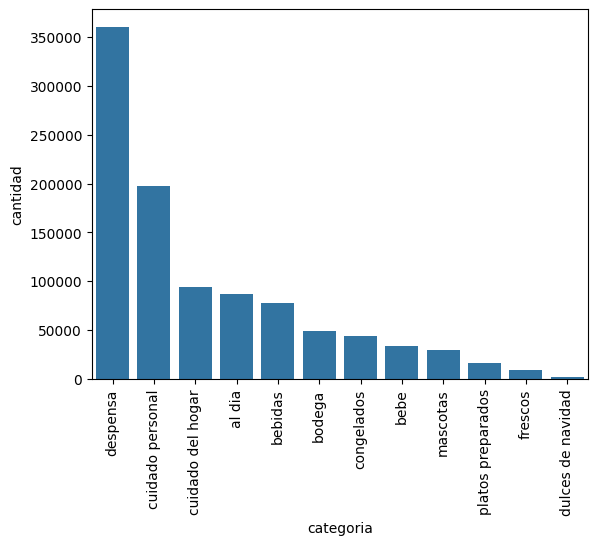

In [66]:
sns.barplot(data=df_categoria, x='categoria', y='cantidad')
plt.xticks(rotation= 90)

In [70]:
#Dentro de cada categoría, ¿quien tiene más subcategorías?
df_categoria_sub = df_final.groupby(['categoria', 'subcategoria']).size().reset_index()
df_categoria_sub.rename(columns={0:'cantidad'}, inplace=True)
df_categoria_sub.sort_values(by='cantidad', ascending=False, inplace=True)
df_categoria_sub


,categoria,subcategoria,cantidad
56,despensa,desayunos y dulces,140457
44,cuidado personal,bano e higiene personal,87200
47,cuidado personal,cuidado corporal,53499
58,despensa,lacteos y huevos,50679
1,al dia,charcuteria y quesos,40970
...,...,...,...
66,dulces de navidad,mantecados y polvorones,192
68,dulces de navidad,panettones,146
67,dulces de navidad,mazapanes,111
69,dulces de navidad,roscones de reyes,41


In [73]:
#¿Qué categoría es la que tiene los precios más altos? ¿y los mínimos? ¿Cuál es su media?
df_final.groupby(['categoria'])['price'].agg(['min', 'max', 'mean']).sort_values(by='mean', ascending=False)

,min,max,mean
categoria,,,
frescos,0.58,289.00,8.114875
bodega,0.65,33.84,6.276739
cuidado personal,0.65,44.99,4.842509
bebe,0.75,25.74,4.670568
mascotas,0.37,28.99,4.545073
al dia,0.18,135.00,3.792475
cuidado del hogar,0.25,60.00,3.577048
congelados,0.49,22.89,3.069315
platos preparados,0.49,9.49,2.661488


In [77]:
df_final['price'].max()

np.float64(289.0)

In [78]:
df_final['price'].min()

np.float64(0.08)

In [79]:
percentil_99 = df_final['price'].quantile(0.99)
filtered_prices = df_final[df_final['price'] <= percentil_99]

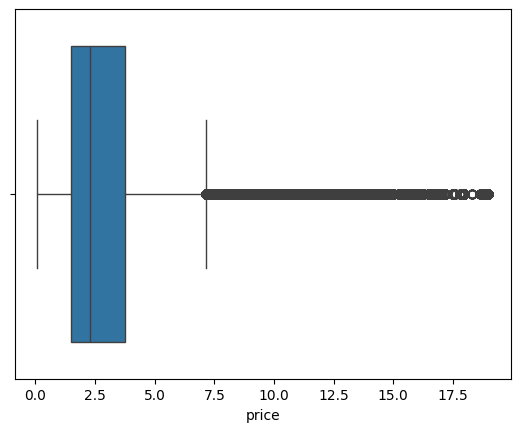

In [85]:
# Análisis de precios y productos
# ¿Existen productos con precios fuera de lo común (outliers)?
sns.boxplot(x='price', data = filtered_prices);

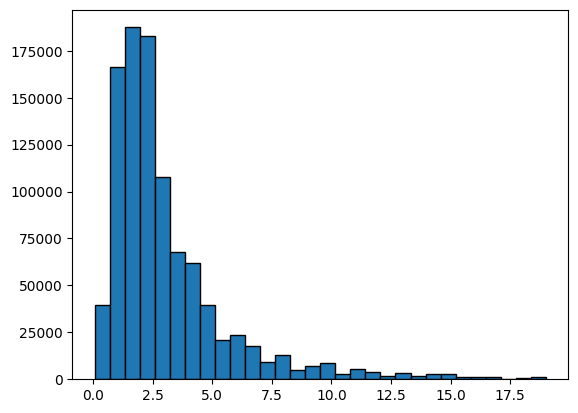

In [89]:
plt.hist(x='price', data= filtered_prices, bins=30, edgecolor= 'black'); 

In [93]:
# ¿Cuántos productos tienen un precio superior al precio de referencia?
productos_mas_caros = df_final[df_final['price'] > df_final['reference_price']]
productos_mas_caros.shape

(154670, 12)

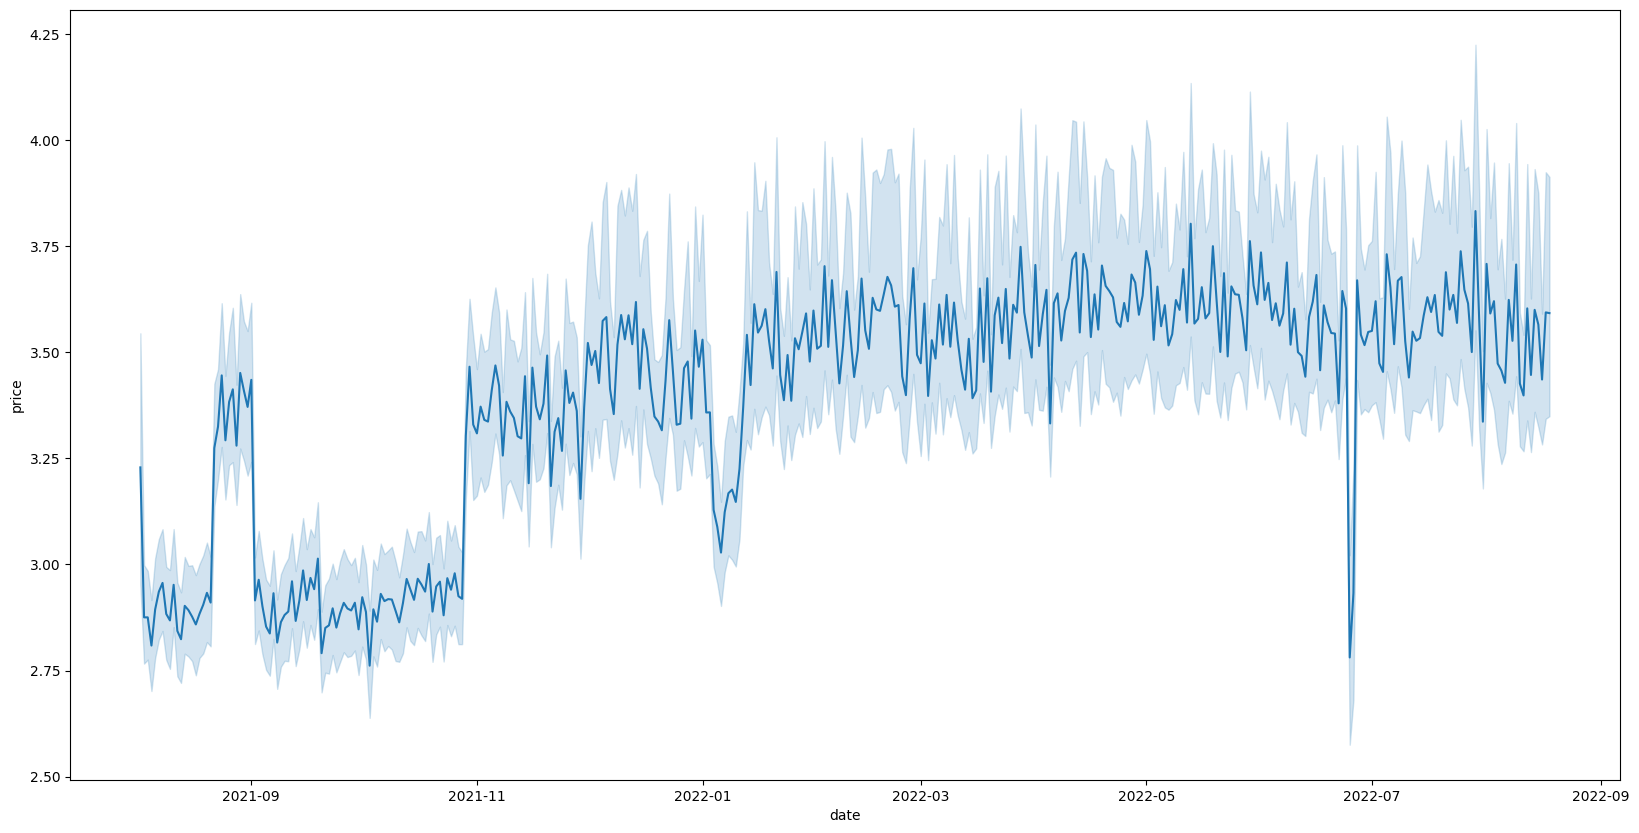

In [95]:
#¿Cómo varían los precios de los productos a lo largo del tiempo? ## lineplot

plt.figure(figsize=(20, 10))
sns.lineplot(data= df_final, x= 'date', y= 'price');


In [100]:
# ¿Qué productos tienen más registros de precios?
df_final.groupby('name').size().reset_index().sort_values(by=0, ascending=False)

,name,0
4711,ESTRELLA GALICIA cerveza especial lata 33 cl P...,368
386,ASTURIANA leche semidesnatada botella 2.2 lt P...,361
389,ASTURIANA leche semidesnatada sin lactosa enva...,356
218,AQUABONA agua mineral natural botella 1.5 lt,350
8635,SOLAN DE CABRAS agua mineral natural botella 1...,349
...,...,...
428,AXE desodorante ice chill antitranspirante spr...,1
6325,LACASA trufas al cacao con coco caja 100 gr,1
371,ASPOLVIT serum facial día y noche triple acció...,1
22,ADIDAS colonia get ready for her frasco 50 ml,1


In [99]:
df_final['product_id'].value_counts().reset_index()

,product_id,count
0,dec17046c7afb4e5a02252f79738045b,368
1,6c738b9d8f185c3c1eda643516675a1c,361
2,17c01da71d8e7a36cf32fd6f34f29625,356
3,5a0a1bb342bf791eb3296626d0dc88ec,350
4,25ca80747ce1c7e7ca65445daafb6262,349
...,...,...
9464,2ac5a1180509afe6b2e3f6655158c2df,1
9465,4b25c3de27904045a711f9a732d2fd1d,1
9466,2936d24c5540a1e7f0f1790c7ad7ee6a,1
9467,7f99a886ce8ee22cbe51e77aa41de713,1


In [106]:
#- ¿Cuántos productos distintos hay en el dataset?
len(df_final['product_id'].value_counts())

9469